In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold

torch.set_printoptions(sci_mode=False, precision=6)
device = torch.device("cpu")

In [2]:
    
if __name__ == '__main__':

    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 12             # number of heads
    ncum = 2                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 100
    target_sample_size = 8  
    nrepp = 10
    

    
    n = 100
    p = 10
    maxlen = 10
    
    # Set the random seed for reproducibility
    seed = 42
    # seed = int(time.time())
    torch.manual_seed(seed) 
    
    # Create Dataset and DataLoader
    train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
   
    predindex = 2


    n = len(train_dataset)
    p = train_dataset[0].shape[1]
    print("Sample size: ", len(train_dataset), "\n")
    




    mask_pairwise = create_custom_mask_pair(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    # eval_dataloader = DataLoader(eval_dataset, batch_size=1000, shuffle=False, collate_fn=collate_function, num_workers=0)

    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise, pairwise_distance_matrix, distance_to_end_matrix,  device)


    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, None, optimizer, lambda_l2, EPOCHS, device)

    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"\n Execution time: {execution_time:.6f} seconds \n")


Sample size:  100 

Number of Parameters 452
EPOCH 1:
avg_loss:     16.45344 penalty    : 0.01495
EPOCH 11:
avg_loss:     7.43647 penalty    : 0.01461
EPOCH 21:
avg_loss:     7.31325 penalty    : 0.02021
EPOCH 31:
avg_loss:     7.19875 penalty    : 0.02743
EPOCH 41:
avg_loss:     7.11215 penalty    : 0.03386
EPOCH 51:
avg_loss:     7.02486 penalty    : 0.03876
EPOCH 61:
avg_loss:     6.92282 penalty    : 0.04299
EPOCH 71:
avg_loss:     6.86393 penalty    : 0.04730
EPOCH 81:
avg_loss:     6.80771 penalty    : 0.05119
EPOCH 91:
avg_loss:     6.76916 penalty    : 0.05474

 Execution time: 6.852344 seconds 



In [3]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.1460 ± 0.32
Variable 2: 0.1285 ± 0.32
Variable 3: 0.0022 ± 0.00
Variable 4: 0.6313 ± 0.19
Variable 5: 0.4497 ± 0.42
Variable 6: 0.4561 ± 0.29
Variable 7: 0.6777 ± 0.10
Variable 8: 0.2242 ± 0.40
Variable 9: 0.6363 ± 0.18
Variable 10: 0.5834 ± 0.13


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall)    

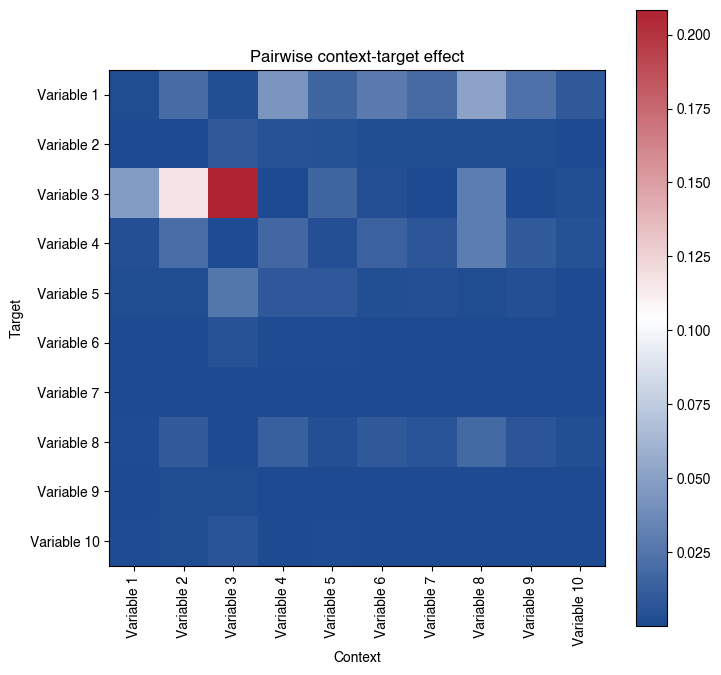

In [6]:
plot = plot_context_predindex_pair_effect(context_predindex_pair_effect, f"{data_str}_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}", "./notebooks/statistical_testing")

In [7]:
with open(f"./notebooks/statistical_testing/statistical_testing_{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}.txt", "a") as f:
    f.write(f"For combination sample size: {target_sample_size} \n")
    for i in range(avepval.shape[0]):
        f.write(f"Variable {i+1}: {avepval[i]:.4f} ± {stdpval[i]:.2f}\n")

    

In [8]:
# Get sorted indices
sorted_indices = torch.argsort(avepval)


with open(f"./notebooks/statistical_testing/statistical_testing_{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}.txt", "a") as f:
    # for loop print name average and standard deviation
    for i in range(avepval.shape[0]):
        print(f"Feature {sorted_indices[i]+1}: {avepval[sorted_indices[i]]:.4f} ± {stdpval[sorted_indices[i]]:.2f}")


Feature 3: 0.0022 ± 0.00
Feature 2: 0.1285 ± 0.32
Feature 1: 0.1460 ± 0.32
Feature 8: 0.2242 ± 0.40
Feature 5: 0.4497 ± 0.42
Feature 6: 0.4561 ± 0.29
Feature 10: 0.5834 ± 0.13
Feature 4: 0.6313 ± 0.19
Feature 9: 0.6363 ± 0.18
Feature 7: 0.6777 ± 0.10


In [9]:
import matplotlib.pyplot as plt

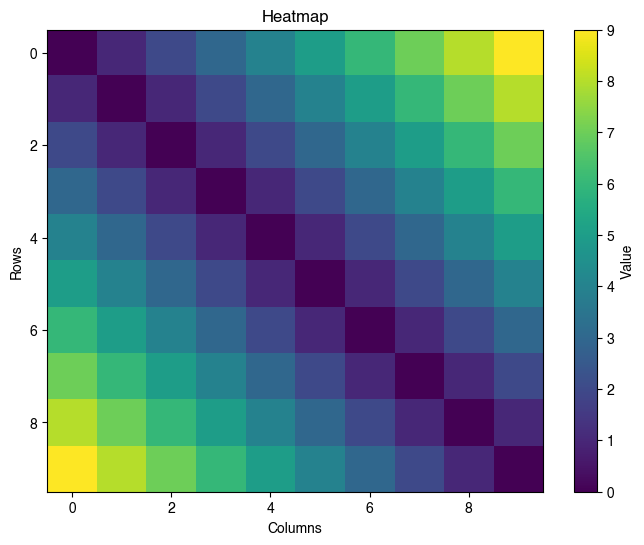

In [10]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(pairwise_distance_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title('Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [11]:
pair_matrix = torch.exp(model.multiheadattn.exponential_decay_pair(pairwise_distance_matrix, model.multiheadattn.distance_between_two_positions_weight)+ create_custom_mask_pair(maxlen, device)).detach().numpy()

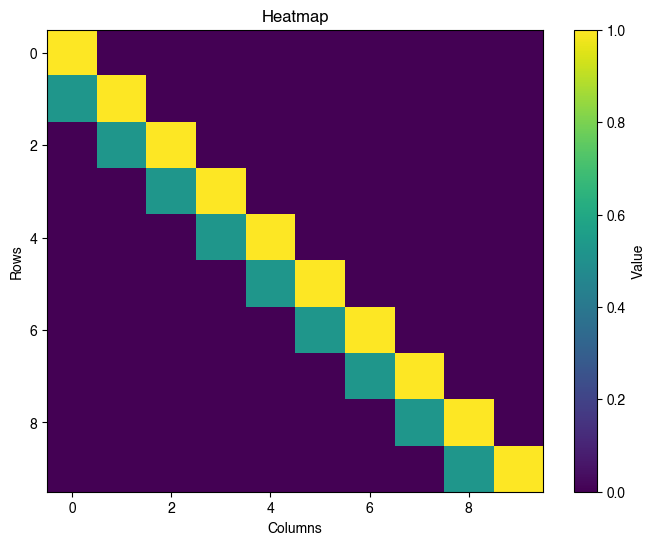

In [12]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(pair_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title('Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [13]:
pred_matrix = model.multiheadattn.exponential_decay_pred(distance_to_end_matrix, model.multiheadattn.distance_to_end_weight).detach().numpy()

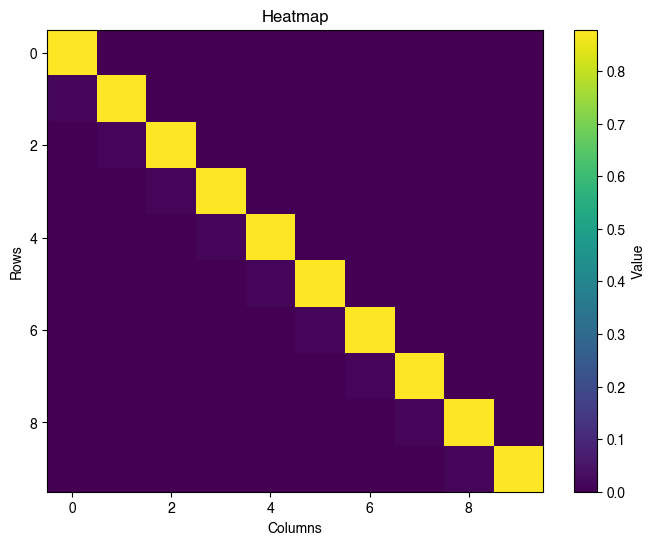

In [14]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(pred_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title('Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

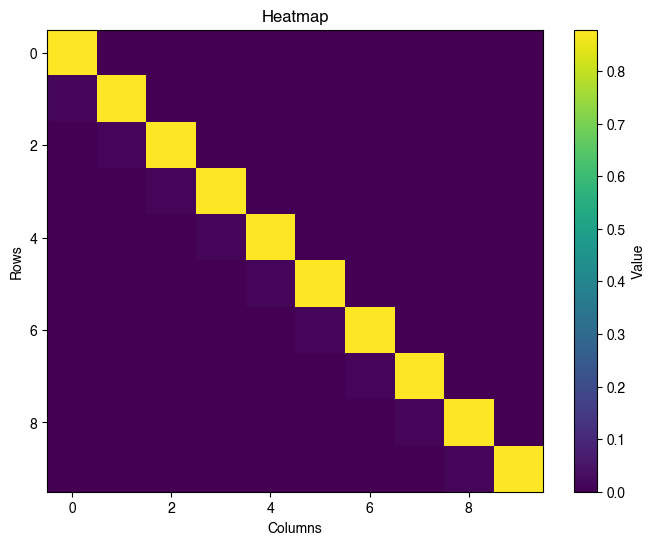

In [15]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(pred_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title('Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()